In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# =========================================================
# 2. Malla espacial (centros de celda)
# =========================================================
Nx = 30
x = np.array([i - 0.5 for i in range(1, Nx + 1)], dtype=float)
times = [i for i in range(0, 41)]

# =========================================================
# 3. Parámetros físicos
# =========================================================
ue = 1.0
u0 = 1.0
V  = 0.4
Ve = 0.4
DL = 0.4
DT = 0.2
n  = 0.5
x0 = 10.5          # centro del pulso
M0 = 199.0         # "masa" inicial discreta en t=0 (impulso)
K = 1 / 30359.9

# =========================================================
# 4. Función u(x,t)
# =========================================================
def u_sol(x, t):
    # --- Condición inicial discreta en t=0 ---
    if t == 0:
        u = np.full_like(x, u0, dtype=float)
        # poner el impulso exactamente en x=10.5 (si existe) o en la celda más cercana
        idx = int(np.argmin(np.abs(x - x0)))
        u[idx] = u0 + M0
        return u

    # --- Para t>0: tu ecuación (2) ---
    M_t = (ue * Ve ) / (4 * n * math.pi * DT * t)  # M(t)

    #pref = M_t / math.sqrt(4 * math.pi * DL * t)
    pref = M0 / math.sqrt(4 * math.pi * DL * t)
    expo = np.exp(-((x - x0 - V*t)**2) / (4 * DL * t))

    return u0 + pref * expo

In [15]:
# =========================================================
# 5. Precalcular soluciones
# =========================================================
u_pulso = {t: u_sol(x, t) for t in times}
c1_sol = lambda u, K: (u + np.sqrt(u*u + 4 * K) ) / 2
c2_sol = lambda u, K: (-u + np.sqrt(u*u + 4 * K) ) / 2

c1 = {t: c1_sol(u_pulso[t], K) for t in times}
c2 = {t: c2_sol(u_pulso[t], K) for t in times}

In [30]:
print(c1)

{0: array([  1.00003294,   1.00003294,   1.00003294,   1.00003294,
         1.00003294,   1.00003294,   1.00003294,   1.00003294,
         1.00003294,   1.00003294, 200.00000016,   1.00003294,
         1.00003294,   1.00003294,   1.00003294,   1.00003294,
         1.00003294,   1.00003294,   1.00003294,   1.00003294,
         1.00003294,   1.00003294,   1.00003294,   1.00003294,
         1.00003294,   1.00003294,   1.00003294,   1.00003294,
         1.00003294,   1.00003294]), 1: array([ 1.00003294,  1.00003294,  1.00003294,  1.00003294,  1.00003294,
        1.00003402,  1.00052638,  1.06466188,  3.425268  , 27.07398604,
       81.31352778, 71.8764396 , 18.92037197,  2.2981616 ,  1.02697426,
        1.00019314,  1.00003321,  1.00003294,  1.00003294,  1.00003294,
        1.00003294,  1.00003294,  1.00003294,  1.00003294,  1.00003294,
        1.00003294,  1.00003294,  1.00003294,  1.00003294,  1.00003294]), 2: array([ 1.00003294,  1.00003294,  1.00003294,  1.00003328,  1.00006621,
      

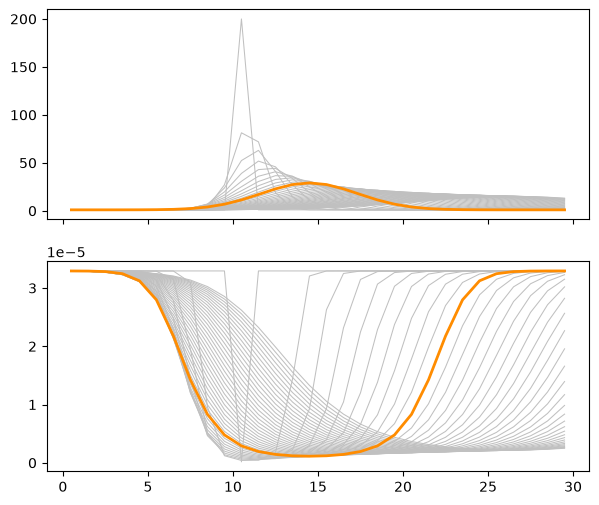

In [29]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(7,6))

color = "silver"
lw = 0.75
for t in times:
    ax[0].plot(x, c1[t], c = color, lw = lw)
    ax[1].plot(x, c2[t], c = color, lw = lw)

tsel = 10
color = "darkorange"
lw = 2.0
ax[0].plot(x, c1[tsel], c = color, lw = lw)
ax[1].plot(x, c2[tsel], c = color, lw = lw)


In [32]:
print("\n-> Writting final results:")
with open("gypsum_exact_species_conc.dat", "w") as f:
    for t in times:
        print(t)
        l1 = [c for c in c1[t].astype(str)]
        l1.insert(0, f"{t:4.2f}")
        l1.append("\n")
        l2 = [c for c in c1[t].astype(str)]
        l2.insert(0, f"{t:4.2f}")
        l2.append("\n")
        f.write(" ".join(l1))
        f.write(" ".join(l2))


-> Writting final results:
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
